<a href="https://colab.research.google.com/github/phaneendra-simhadri/23CSE301/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Lab Session Data.xlsx to Lab Session Data.xlsx


In [ ]:
import pandas as pd

data = pd.read_excel('Lab Session Data.xlsx',sheet_name=3)

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

def lebelencoding(d,c):
  d = data.copy()
  encode = LabelEncoder()

  for col in c:
    d[col] = encode.fit_transform(d[col])

    return d

def onehotencoding(d,c):
  d = data.copy()
  d = pd.get_dummies(d, columns=c)
  return d









In [ ]:
categorical_cols = ["Education", "Marital_Status"]


label_df = lebelencoding(data, categorical_cols)
onehot_df = onehotencoding(data, categorical_cols)

print("One Hot Shape :", onehot_df.shape)

print("Label Encoded Shape :", label_df.shape)

print("Original Shape :", data.shape)

One Hot Shape : (2240, 40)
Label Encoded Shape : (2240, 29)
Original Shape : (2240, 29)


In [ ]:
def minkowski(a,b,n):
  sum = 0
  for i in range(len(a)):
    sum += abs(a[i] - b[i]) ** n;
  return sum **(1/n)


A = [5, 8]
B = [8, 4]

print(minkowski(A,B,1))
print(minkowski(A,B,2))
print(minkowski(A,B,3))
print(minkowski(A,B,4))

7.0
5.0
4.497941445275415
4.284572294953817


[np.float64(16781.0), np.float64(12290.371231171172), np.float64(11884.37455405266), np.float64(11813.182056643884), np.float64(11798.3594656484), np.float64(11795.03214977206), np.float64(11794.251319225397), np.float64(11794.062464516399), np.float64(11794.015771376238), np.float64(11794.004031784574)]


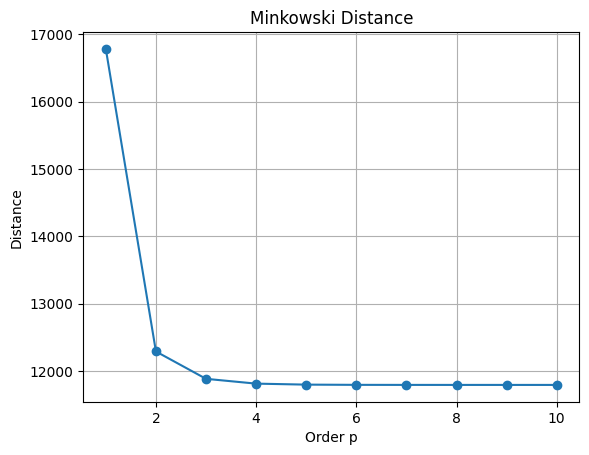

In [ ]:
import matplotlib.pyplot as plt

numeric_df = data.select_dtypes(include=["number"])
A = numeric_df.iloc[0].values

B = numeric_df.iloc[1].values

p_values = []
distances = []

for p in range(1,11):

    d = minkowski(A,B,p)

    p_values.append(p)
    distances.append(d)

print(distances)

plt.plot(p_values,distances,marker='o')

plt.title("Minkowski Distance")

plt.xlabel("Order p")

plt.ylabel("Distance")

plt.grid(True)

plt.show()

In [ ]:
from scipy.spatial.distance import minkowski
def my_minkowski(a, b, p):
    total = 0

    for i in range(len(a)):
        total += abs(a[i] - b[i]) ** p

    return total ** (1 / p)

numeric_df = data.select_dtypes(include=["number"])
A = numeric_df.iloc[0].values

B = numeric_df.iloc[1].values

p_values = []
distances = []


for p in range(1, 11):

    my_distance = my_minkowski(A, B, p)

    scipy_distance = minkowski(A, B, p)

    print(f"p = {p}")
    print("My Function   :", my_distance)
    print("SciPy Function:", scipy_distance)
    print()

p = 1
My Function   : 16781.0
SciPy Function: 16781.0

p = 2
My Function   : 12290.371231171172
SciPy Function: 12290.371231171172

p = 3
My Function   : 11884.37455405266
SciPy Function: 11884.37455405266

p = 4
My Function   : 11813.182056643884
SciPy Function: 11813.182056643884

p = 5
My Function   : 11798.3594656484
SciPy Function: 11798.3594656484

p = 6
My Function   : 11795.03214977206
SciPy Function: 11795.03214977206

p = 7
My Function   : 11794.251319225397
SciPy Function: 11794.251319225397

p = 8
My Function   : 11794.062464516399
SciPy Function: 11794.062464516399

p = 9
My Function   : 11794.015771376238
SciPy Function: 11794.015771376238

p = 10
My Function   : 11794.004031784574
SciPy Function: 11794.004031784574



In [ ]:
import numpy as np

def dot_product(A, B):
    total = 0

    for i in range(len(A)):
        total += A[i] * B[i]

    return total


def euclidean_norm(vector):
    total = 0

    for value in vector:
        total += value ** 2

    return total ** 0.5


numeric_df = data.select_dtypes(include=["number"])
A = numeric_df.iloc[0].values

B = numeric_df.iloc[1].values

p_values = []
distances = []

print("----- Dot Product -----")
print("My Function :", dot_product(A, B))
print("NumPy       :", np.dot(A, B))

print()

print("----- Euclidean Norm -----")
print("My Norm (A) :", euclidean_norm(A))
print("NumPy (A)   :", np.linalg.norm(A))

print("My Norm (B) :", euclidean_norm(B))
print("NumPy (B)   :", np.linalg.norm(B))

----- Dot Product -----
My Function : 2710194336.0
NumPy       : 2710194336.0

----- Euclidean Norm -----
My Norm (A) : 58439.10812974476
NumPy (A)   : 58439.10812974476
My Norm (B) : 46436.11243418208
NumPy (B)   : 46436.11243418208


In [ ]:
def mean(data):
    total = 0

    for value in data:
        total += value

    return total / len(data)


def variance(data):
    avg = mean(data)

    total = 0

    for value in data:
        total += (value - avg) ** 2

    return total / len(data)


def standard_deviation(data):
    return variance(data) ** 0.5


for column in numeric_df.columns:

    values = numeric_df[column].tolist()

    print("Feature:", column)
    print("Mean:", mean(values))
    print("Variance:", variance(values))
    print("Standard Deviation:", standard_deviation(values))
    print()

Feature: ID
Mean: 5592.159821428571
Variance: 10536109.703921402
Standard Deviation: 3245.9374152810465

Feature: Year_Birth
Mean: 1968.8058035714287
Variance: 143.5538056042729
Standard Deviation: 11.98139414276456

Feature: Income
Mean: nan
Variance: nan
Standard Deviation: nan

Feature: Kidhome
Mean: 0.44419642857142855
Variance: 0.28974310427295247
Standard Deviation: 0.5382779061720372

Feature: Teenhome
Mean: 0.50625
Variance: 0.296389508928571
Standard Deviation: 0.5444166684889167

Feature: Recency
Mean: 49.109375
Variance: 838.4491978236607
Standard Deviation: 28.955987253479385

Feature: MntWines
Mean: 303.9357142857143
Variance: 113247.2253316325
Standard Deviation: 336.5222508715174

Feature: MntFruits
Mean: 26.302232142857143
Variance: 1581.219816446118
Standard Deviation: 39.76455477490121

Feature: MntMeatProducts
Mean: 166.95
Variance: 50924.685000000325
Standard Deviation: 225.66498399175785

Feature: MntFishProducts
Mean: 37.52544642857143
Variance: 2982.993102479231


In [ ]:
import numpy as np

def mean(data):
    total = 0

    for value in data:
        total += value

    return total / len(data)


def variance(data):
    avg = mean(data)

    total = 0

    for value in data:
        total += (value - avg) ** 2

    return total / len(data)


def standard_deviation(data):
    return variance(data) ** 0.5


for column in numeric_df.columns:

    values = numeric_df[column].tolist()

    print("Feature :", column)

    print("My Mean       :", mean(values))
    print("NumPy Mean    :", np.mean(values))

    print("My Std Dev    :", standard_deviation(values))
    print("NumPy Std Dev :", np.std(values))

    print("-"*40)

Feature : ID
My Mean       : 5592.159821428571
NumPy Mean    : 5592.159821428571
My Std Dev    : 3245.9374152810465
NumPy Std Dev : 3245.9374152810456
----------------------------------------
Feature : Year_Birth
My Mean       : 1968.8058035714287
NumPy Mean    : 1968.8058035714287
My Std Dev    : 11.98139414276456
NumPy Std Dev : 11.981394142764563
----------------------------------------
Feature : Income
My Mean       : nan
NumPy Mean    : nan
My Std Dev    : nan
NumPy Std Dev : nan
----------------------------------------
Feature : Kidhome
My Mean       : 0.44419642857142855
NumPy Mean    : 0.44419642857142855
My Std Dev    : 0.5382779061720372
NumPy Std Dev : 0.5382779061720435
----------------------------------------
Feature : Teenhome
My Mean       : 0.50625
NumPy Mean    : 0.50625
My Std Dev    : 0.5444166684889167
NumPy Std Dev : 0.5444166684889171
----------------------------------------
Feature : Recency
My Mean       : 49.109375
NumPy Mean    : 49.109375
My Std Dev    : 28.9

Mean : nan
Variance : nan


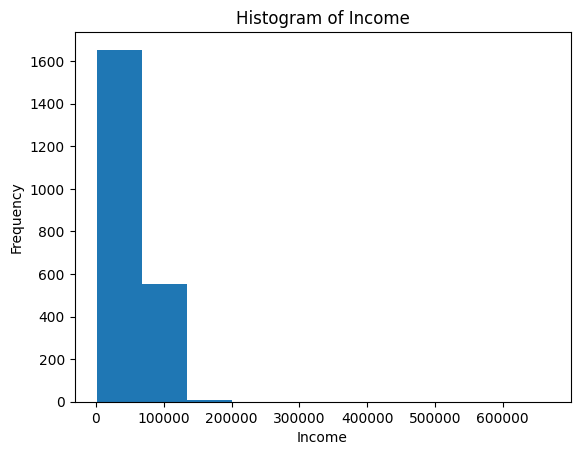

In [ ]:
import matplotlib.pyplot as plt

# Select one numeric feature
feature = numeric_df["Income"]

# Calculate statistics
avg = mean(feature.tolist())
var = variance(feature.tolist())

print("Mean :", avg)
print("Variance :", var)

# Plot Histogram
plt.hist(feature, bins=10)

plt.title("Histogram of Income")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.cluster import KMeans

# -----------------------------
# Load Dataset
# -----------------------------
data = pd.read_excel("Lab Session Data.xlsx", sheet_name=3)

# Keep only numeric columns
numeric_df = data.select_dtypes(include=[np.number])

# Remove rows containing missing values
numeric_df = numeric_df.dropna()

# Convert to NumPy array
dataset = numeric_df.values

# -----------------------------
# Euclidean Distance
# -----------------------------
def euclidean_distance(a, b):
    total = 0

    for i in range(len(a)):
        total += (a[i] - b[i]) ** 2

    return total ** 0.5


# -----------------------------
# Assign Clusters
# -----------------------------
def assign_clusters(data, centroids):

    clusters = []

    for point in data:

        distances = []

        for centroid in centroids:
            distances.append(euclidean_distance(point, centroid))

        clusters.append(distances.index(min(distances)))

    return clusters


# -----------------------------
# Update Centroids
# -----------------------------
def update_centroids(data, clusters, k):

    centroids = []

    for i in range(k):

        cluster_points = []

        for j in range(len(data)):

            if clusters[j] == i:
                cluster_points.append(data[j])

        cluster_points = np.array(cluster_points)

        if len(cluster_points) > 0:
            centroids.append(cluster_points.mean(axis=0))
        else:
            centroids.append(data[np.random.randint(len(data))])

    return np.array(centroids)


# -----------------------------
# My K-Means
# -----------------------------
def my_kmeans(data, k, max_iterations=100):

    centroids = data[:k].copy()

    for _ in range(max_iterations):

        clusters = assign_clusters(data, centroids)

        new_centroids = update_centroids(data, clusters, k)

        if np.allclose(new_centroids, centroids):
            break

        centroids = new_centroids

    return np.array(clusters), centroids


# =====================================
# MY IMPLEMENTATION
# =====================================

start = time.time()

my_clusters, my_centroids = my_kmeans(dataset, 3)

end = time.time()

my_time = end - start


# =====================================
# AI / SCIKIT IMPLEMENTATION
# =====================================

start = time.time()

model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

model.fit(dataset)

ai_clusters = model.labels_

ai_centroids = model.cluster_centers_

end = time.time()

ai_time = end - start


# =====================================
# RESULTS
# =====================================

print("="*60)
print("MY IMPLEMENTATION")
print("="*60)

print("Clusters")
print(my_clusters)

print()

print("Centroids")
print(my_centroids)

print()

print("Execution Time :", my_time)


print("\n")
print("="*60)
print("AI IMPLEMENTATION")
print("="*60)

print("Clusters")
print(ai_clusters)

print()

print("Centroids")
print(ai_centroids)

print()

print("Execution Time :", ai_time)


print("\n")
print("="*60)
print("PERFORMANCE COMPARISON")
print("="*60)

print("My K-Means Time :", my_time)
print("AI K-Means Time :", ai_time)

if my_time < ai_time:
    print("My implementation is faster.")
elif ai_time < my_time:
    print("AI implementation is faster.")
else:
    print("Both implementations have similar execution time.")

print("\n")

comparison = pd.DataFrame({
    "Feature": [
        "Distance",
        "Centroid Update",
        "Execution Time"
    ],
    "My Implementation": [
        "Own Euclidean Function",
        "Manual",
        my_time
    ],
    "AI Implementation": [
        "Optimized Euclidean",
        "Library Function",
        ai_time
    ]
})

print(comparison)

MY IMPLEMENTATION
Clusters
[0 0 2 ... 0 2 0]

Centroids
[[5.54909136e+03 1.96533827e+03 5.56852568e+04 3.30864198e-01
  8.23456790e-01 4.93111111e+01 3.47049383e+02 2.29259259e+01
  1.24369136e+02 3.16456790e+01 2.19308642e+01 4.97234568e+01
  3.06913580e+00 5.07530864e+00 2.68148148e+00 6.72839506e+00
  5.40493827e+00 5.80246914e-02 1.00000000e-01 1.11111111e-02
  2.46913580e-02 1.72839506e-02 7.40740741e-03 3.00000000e+00
  1.10000000e+01 1.01234568e-01]
 [5.58414815e+03 1.97283871e+03 2.98794719e+04 7.95698925e-01
  3.47670251e-01 4.87718041e+01 3.90107527e+01 6.44563919e+00
  2.79820789e+01 9.52090800e+00 6.36200717e+00 1.91612903e+01
  2.21146953e+00 2.28434886e+00 5.93787336e-01 3.18996416e+00
  6.83632019e+00 8.60215054e-02 5.97371565e-03 0.00000000e+00
  1.19474313e-03 0.00000000e+00 1.55316607e-02 3.00000000e+00
  1.10000000e+01 1.18279570e-01]
 [5.65043058e+03 1.96786643e+03 8.02561213e+04 7.90861160e-02
  2.84710018e-01 4.89420035e+01 6.36768014e+02 6.05272408e+01
  4.321669